In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Dataset Cleaning
We verify images first to ensure no corrupted files interfere with the generators.

This section prepares the dataset by organizing image folders, removing corrupted or invalid files, and ensuring that the data is ready for training and evaluation. Proper cleaning improves model accuracy and reduces training errors.

This code cell mounts Google Drive, defines source and destination paths for the dataset, and includes a function (`clean_and_copy`) to verify image integrity and copy valid images to a new directory. Finally, it runs the cleaning process for both training and testing datasets.

In [6]:
from google.colab import drive
import os
import shutil
from PIL import Image

# 1. MOUNT GOOGLE DRIVE
drive.mount('/content/drive')

# 2. DEFINE SOURCE PATHS (From your Drive)
base_source_dir = '/content/drive/MyDrive/AI and Machine Learning/Scene Classification'
train_src = os.path.join(base_source_dir, 'train')
test_src = os.path.join(base_source_dir, 'test')

# 3. DEFINE DESTINATION PATHS (Local Colab runtime storage)
clean_train_dir = '/content/clean_data/train'
clean_test_dir = '/content/clean_data/test'

def clean_and_copy(src, dst):
    """Verifies images and copies only valid ones to a new directory."""
    if not os.path.exists(dst):
        os.makedirs(dst)

    total, kept = 0, 0

    # Iterate through classes (sea, mountain, etc.)
    for cls in os.listdir(src):
        s_path = os.path.join(src, cls)
        d_path = os.path.join(dst, cls)

        if not os.path.isdir(s_path): continue
        if not os.path.exists(d_path): os.makedirs(d_path)

        for f in os.listdir(s_path):
            total += 1
            f_path = os.path.join(s_path, f)
            try:
                with Image.open(f_path) as img:
                    img.verify() # Check for corruption
                # Re-open because verify() closes the file handle
                shutil.copy2(f_path, os.path.join(d_path, f))
                kept += 1
            except Exception:
                # This skips corrupted files
                pass

    print(f'Processed {src}: Kept {kept}/{total} valid images.')

# Run the cleaning process
clean_and_copy(train_src, clean_train_dir)
clean_and_copy(test_src, clean_test_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processed /content/drive/MyDrive/AI and Machine Learning/Scene Classification/train: Kept 13992/14034 valid images.
Processed /content/drive/MyDrive/AI and Machine Learning/Scene Classification/test: Kept 3000/3000 valid images.


# 2. Data Understanding
Visualizing class distribution and samples from the cleaned dataset.

In this section, the dataset is explored through visualizations and statistical analysis. The goal is to understand class distribution, image dimensions, and overall dataset characteristics before model development.

This code cell imports `matplotlib.pyplot` for plotting. It calculates the number of images in each class within the cleaned training directory and then visualizes this class distribution using a bar chart. It also prints the total number of cleaned training images.

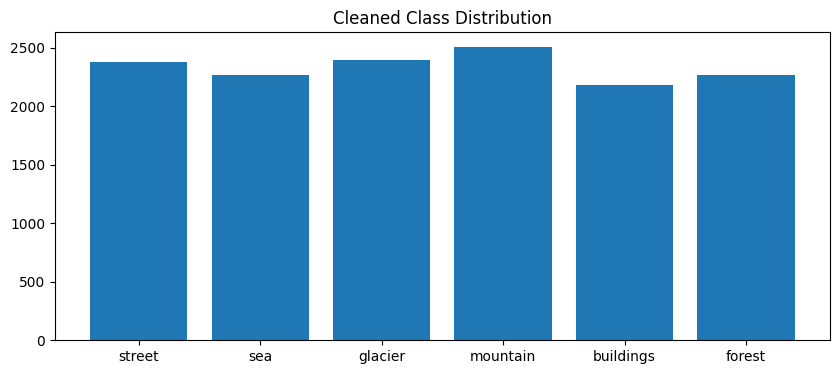

Total Clean Training Images: 13992


In [7]:
import matplotlib.pyplot as plt

classes = os.listdir(clean_train_dir)
counts = {c: len(os.listdir(os.path.join(clean_train_dir, c))) for c in classes}

plt.figure(figsize=(10, 4))
plt.bar(counts.keys(), counts.values())
plt.title("Cleaned Class Distribution")
plt.show()

print(f"Total Clean Training Images: {sum(counts.values())}")

This code cell imports `numpy` and then iterates through each class to display a sample image from the `clean_train_dir`. It visualizes these sample images in a grid, along with their respective class names and image counts.

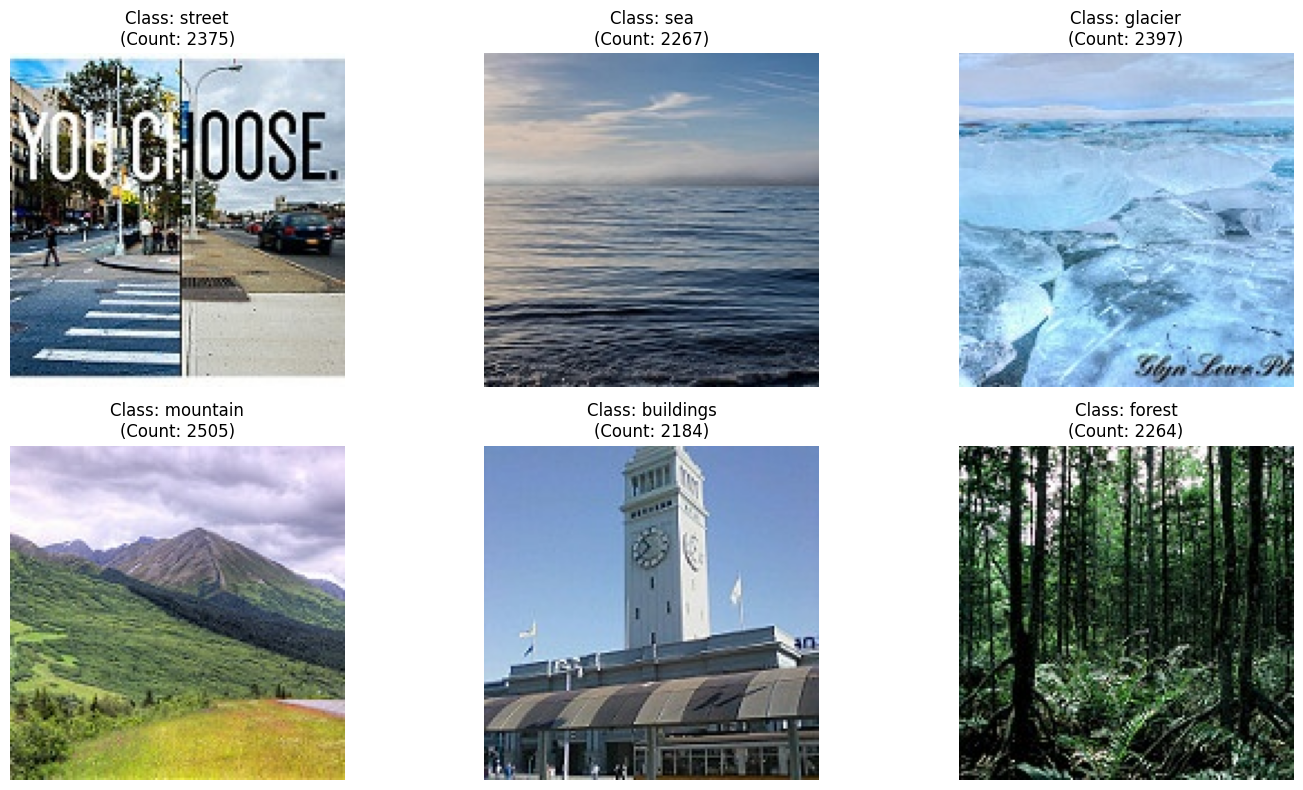

In [8]:
import numpy as np

# Visualize sample images from each class
plt.figure(figsize=(15, 8))
for i, cls in enumerate(classes):
    cls_path = os.path.join(clean_train_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {cls}\n(Count: {counts[cls]})")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 3. Data Generators (128x128)
Creating standardized generators for the custom CNN models.

Image data generators are used to preprocess and augment the dataset. Images are resized to 128x128 pixels, normalized, and augmented with transformations such as rotation, zoom, and flipping to improve model generalization.

This cell initializes `ImageDataGenerator` from `tensorflow.keras.preprocessing.image` to create data generators for the models. It defines image resizing to 128x128 pixels and includes data augmentation (rotation, horizontal flip) for the training set. Separate generators are created for training, validation, and test sets, with appropriate scaling.

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

size_128 = (128, 128)

train_datagen_128 = ImageDataGenerator(rescale=1./255, validation_split=0.2, rotation_range=20, horizontal_flip=True)
val_datagen_128 = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen_128 = train_datagen_128.flow_from_directory(clean_train_dir, target_size=size_128, batch_size=32, subset='training')
val_gen_128 = val_datagen_128.flow_from_directory(clean_train_dir, target_size=size_128, batch_size=32, subset='validation')
test_gen_128 = ImageDataGenerator(rescale=1./255).flow_from_directory(clean_test_dir, target_size=size_128, batch_size=32, shuffle=False)

Found 11196 images belonging to 6 classes.
Found 2796 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


# 4. Baseline CNN (3 Conv + 3 Dense)
Strictly following the requirement: 3 Conv layers and 3 Dense layers before the output.

A baseline Convolutional Neural Network (CNN) model is created using three convolutional layers and three dense layers. This model serves as the initial benchmark for evaluating classification performance.

This code defines and trains a baseline Convolutional Neural Network (CNN) model using `tensorflow.keras`. The model consists of three `Conv2D` layers followed by `MaxPooling2D` layers, a `Flatten` layer, and three `Dense` layers before the final `softmax` output layer. It is compiled with the Adam optimizer and trained for 10 epochs.

In [10]:
import time
from tensorflow.keras import layers, models

model_baseline = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(classes), activation='softmax')
])

model_baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
start = time.time()
hist_base = model_baseline.fit(train_gen_128, validation_data=val_gen_128, epochs=5)
base_time = time.time() - start
print(f"Baseline Training Time: {base_time:.2f}s")

Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 71s 182ms/step - accuracy: 0.5782 - loss: 1.0756 - val_accuracy: 0.6817 - val_loss: 0.8444
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 168ms/step - accuracy: 0.6981 - loss: 0.8022 - val_accuracy: 0.7661 - val_loss: 0.6586
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.7520 - loss: 0.6756 - val_accuracy: 0.7650 - val_loss: 0.6394
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 169ms/step - accuracy: 0.7842 - loss: 0.5956 - val_accuracy: 0.7600 - val_loss: 0.7002
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 66s 188ms/step - accuracy: 0.8069 - loss: 0.5348 - val_accuracy: 0.7933 - val_loss: 0.5634
Baseline Training Time: 312.91s


# 5. Baseline Evaluation
Calculating Precision, Recall, F1-score and visualizing inference.

The baseline CNN model is evaluated using performance metrics such as accuracy, loss, confusion matrix, and classification reports to measure how well the model performs on unseen data.

This code cell evaluates the `model_baseline` by making predictions on the test set. It then uses `sklearn.metrics.classification_report` to print precision, recall, and F1-score for each class. Finally, it plots the training and validation loss curves over epochs to visualize the model's performance during training.

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step
              precision    recall  f1-score   support

      street       0.72      0.80      0.75       437
         sea       0.95      0.91      0.93       474
     glacier       0.77      0.72      0.75       553
    mountain       0.67      0.83      0.75       525
   buildings       0.90      0.54      0.68       510
      forest       0.76      0.89      0.82       501

    accuracy                           0.78      3000
   macro avg       0.80      0.78      0.78      3000
weighted avg       0.79      0.78      0.78      3000



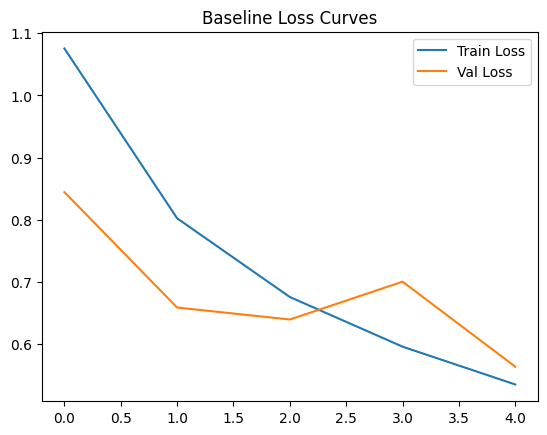

In [11]:
import numpy as np
from sklearn.metrics import classification_report

# Metrics
preds_base = model_baseline.predict(test_gen_128)
y_pred_base = np.argmax(preds_base, axis=1)
print(classification_report(test_gen_128.classes, y_pred_base, target_names=classes))

# Plots
plt.plot(hist_base.history['loss'], label='Train Loss')
plt.plot(hist_base.history['val_loss'], label='Val Loss')
plt.title('Baseline Loss Curves')
plt.legend()
plt.show()

# 6. Deeper CNN with Regularization
This model has double the layers of the baseline and includes BatchNorm and Dropout.

A deeper CNN architecture is implemented with regularization techniques such as dropout and batch normalization. These methods help reduce overfitting and improve model generalization.

This cell defines a deeper CNN model compared to the baseline, incorporating additional convolutional layers, `BatchNormalization` for faster and more stable training, and `Dropout` layers to prevent overfitting in the dense layers. The model is compiled with the Adam optimizer and trained for 10 epochs.

In [12]:
model_deeper = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'), layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'), layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'), layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'), layers.Dropout(0.5),
    layers.Dense(256, activation='relu'), layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(classes), activation='softmax')
])

model_deeper.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
start = time.time()
hist_deep = model_deeper.fit(train_gen_128, validation_data=val_gen_128, epochs=5)
deep_time = time.time() - start
print(f"Deeper Model Training Time: {deep_time:.2f}s")

Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 86s 209ms/step - accuracy: 0.4336 - loss: 1.5790 - val_accuracy: 0.5333 - val_loss: 1.2577
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 61s 175ms/step - accuracy: 0.5734 - loss: 1.0818 - val_accuracy: 0.5637 - val_loss: 1.0796
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 62s 177ms/step - accuracy: 0.6301 - loss: 0.9595 - val_accuracy: 0.6685 - val_loss: 0.8817
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 60s 172ms/step - accuracy: 0.6817 - loss: 0.8494 - val_accuracy: 0.5576 - val_loss: 1.4263
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 60s 171ms/step - accuracy: 0.7134 - loss: 0.7926 - val_accuracy: 0.7239 - val_loss: 0.7560
Deeper Model Training Time: 329.29s


# 7. Optimizer Comparison: SGD vs Adam
Comparing convergence speed and performance.

This section compares the performance of different optimization algorithms, specifically SGD and Adam, to determine which optimizer provides better convergence and accuracy for the CNN model.

This code cell compares the performance of the SGD and Adam optimizers on a simplified CNN model. It defines a `build_comp_model` function, then trains two instances of this model: one with `SGD` and another with `Adam`. After training, it plots the training accuracy for both models over 5 epochs to show their convergence behavior.

Training with SGD...
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 61s 169ms/step - accuracy: 0.4913 - loss: 1.3013 - val_accuracy: 0.5994 - val_loss: 1.0619
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.5919 - loss: 1.0538 - val_accuracy: 0.6327 - val_loss: 0.9622
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 163ms/step - accuracy: 0.6216 - loss: 1.0002 - val_accuracy: 0.6091 - val_loss: 1.0354
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 163ms/step - accuracy: 0.6533 - loss: 0.9247 - val_accuracy: 0.6667 - val_loss: 0.9045
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 161ms/step - accuracy: 0.6634 - loss: 0.8737 - val_accuracy: 0.6642 - val_loss: 0.9050

Training with Adam...
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 61s 168ms/step - accuracy: 0.5782 - loss: 1.2702 - val_accuracy: 0.6831 - val_loss: 0.9410
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 165ms/step - accuracy: 0.6885 - loss: 0.8528 - val_accuracy: 0.7117 - val_loss: 0.8275
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 163

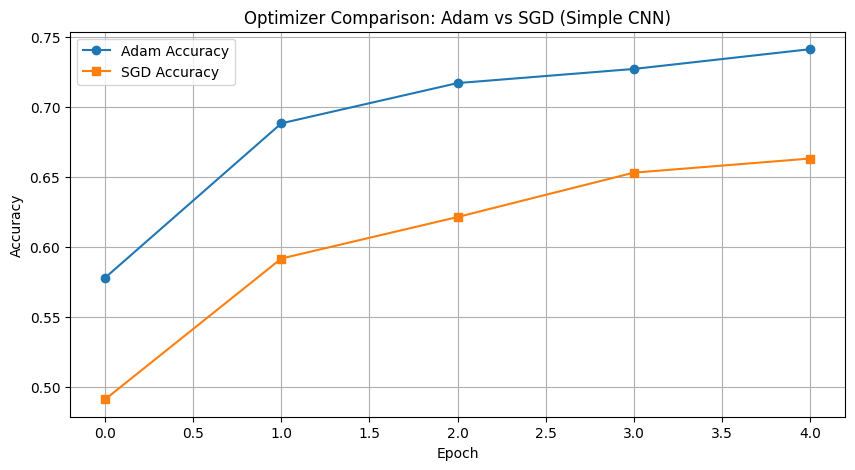

In [13]:
from tensorflow.keras.optimizers import SGD, Adam

# Define a simple version for comparison to keep training fast
def build_comp_model():
    return models.Sequential([
        layers.Input(shape=(128, 128, 3)),
        layers.Conv2D(32, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(len(classes), activation='softmax')
    ])

# 1. Train with SGD
print("Training with SGD...")
model_sgd = build_comp_model()
model_sgd.compile(optimizer=SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
hist_sgd = model_sgd.fit(train_gen_128, validation_data=val_gen_128, epochs=5, verbose=1)

# 2. Train with Adam
print("\nTraining with Adam...")
model_adam_comp = build_comp_model()
model_adam_comp.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
hist_adam_comp = model_adam_comp.fit(train_gen_128, validation_data=val_gen_128, epochs=5, verbose=1)

# Plot Comparison
plt.figure(figsize=(10, 5))
plt.plot(hist_adam_comp.history['accuracy'], label='Adam Accuracy', marker='o')
plt.plot(hist_sgd.history['accuracy'], label='SGD Accuracy', marker='s')
plt.title('Optimizer Comparison: Adam vs SGD (Simple CNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 8. Ablation Study
Removing Dropout to analyze the impact on overfitting.

An ablation study is conducted to analyze the contribution of different components of the model. Certain layers or techniques are removed to observe their impact on performance.

This cell performs an ablation study by creating a simplified CNN model (`model_ablation`) that intentionally removes the `Dropout` layer present in other models. It compiles and trains this model for 10 epochs, then plots the training and validation accuracy curves. The purpose is to observe the impact of removing dropout on model performance and potential overfitting.

Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 62s 169ms/step - accuracy: 0.6045 - loss: 1.3127 - val_accuracy: 0.6924 - val_loss: 0.8389
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.7031 - loss: 0.8135 - val_accuracy: 0.6835 - val_loss: 0.8790
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 163ms/step - accuracy: 0.7270 - loss: 0.7527 - val_accuracy: 0.7339 - val_loss: 0.7560
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 164ms/step - accuracy: 0.7449 - loss: 0.7058 - val_accuracy: 0.7446 - val_loss: 0.7469
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 163ms/step - accuracy: 0.7557 - loss: 0.6753 - val_accuracy: 0.7411 - val_loss: 0.7377


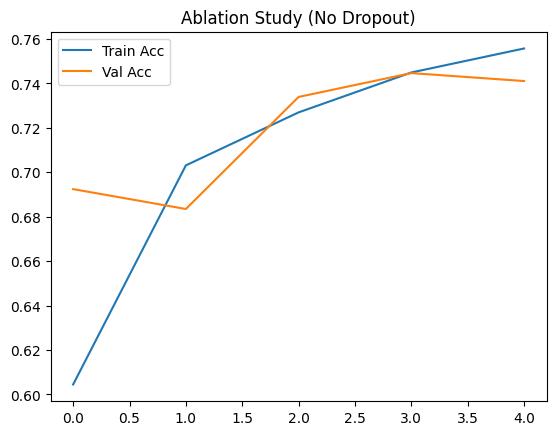

In [14]:
model_ablation = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'), # Dropout removed here
    layers.Dense(len(classes), activation='softmax')
])

model_ablation.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_ablation = model_ablation.fit(train_gen_128, validation_data=val_gen_128, epochs=5)

# Analyze gap between train/val accuracy
plt.plot(hist_ablation.history['accuracy'], label='Train Acc')
plt.plot(hist_ablation.history['val_accuracy'], label='Val Acc')
plt.title('Ablation Study (No Dropout)')
plt.legend()
plt.show()

## 9. Transfer Learning (ResNet50)



This code cell implements the feature extraction phase of transfer learning using ResNet50. It loads `ResNet50` pretrained on ImageNet, sets its layers to `non-trainable` (freezing them), and adds a new classification head with `GlobalAveragePooling2D`, `Dense` layers, and `Dropout`. The model is compiled with Adam and trained for 5 epochs on the new classification head.

In [21]:
from tensorflow.keras.applications import ResNet50
import time


base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model_resnet.trainable = False

model_tl_resnet = models.Sequential([
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(classes), activation='softmax')
])

model_tl_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Starting ResNet50 Feature Extraction...")
start_resnet_fe = time.time()
history_resnet_fe = model_tl_resnet.fit(train_gen_128, validation_data=val_gen_128, epochs=5)
end_resnet_fe = time.time()
resnet_fe_time = end_resnet_fe - start_resnet_fe
print(f"ResNet50 Feature Extraction Time: {resnet_fe_time:.2f}s")

Starting ResNet50 Feature Extraction...
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 89s 216ms/step - accuracy: 0.2887 - loss: 1.6799 - val_accuracy: 0.4474 - val_loss: 1.4880
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 64s 183ms/step - accuracy: 0.3967 - loss: 1.4512 - val_accuracy: 0.4939 - val_loss: 1.3099
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 65s 186ms/step - accuracy: 0.4353 - loss: 1.3502 - val_accuracy: 0.5036 - val_loss: 1.2385
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 71s 203ms/step - accuracy: 0.4491 - loss: 1.3104 - val_accuracy: 0.5322 - val_loss: 1.1919
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 62s 177ms/step - accuracy: 0.4716 - loss: 1.2687 - val_accuracy: 0.5572 - val_loss: 1.1479
ResNet50 Feature Extraction Time: 351.40s


This code cell performs fine-tuning on the `ResNet50` model. It unfreezes the `base_model_resnet` but specifically freezes layers up to a certain point (e.g., the first 140 layers) to selectively retrain only the later layers. The model is then recompiled with a very small learning rate (1e-5) using the Adam optimizer and trained for an additional 5 epochs, allowing fine adjustments to the pre-trained weights.

In [23]:
from tensorflow.keras.optimizers import Adam

base_model_resnet.trainable = True

for layer in base_model_resnet.layers[:140]:
    layer.trainable = False

model_tl_resnet.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

print("Starting ResNet50 Fine-Tuning...")
start_resnet_ft = time.time()
history_resnet_ft = model_tl_resnet.fit(train_gen_128, validation_data=val_gen_128, epochs=5)
end_resnet_ft = time.time()
resnet_ft_time = end_resnet_ft - start_resnet_ft
print(f"ResNet50 Fine-tuning Time: {resnet_ft_time:.2f}s")

total_resnet_time = resnet_fe_time + resnet_ft_time
print(f"Total ResNet50 Transfer Learning Time: {total_resnet_time:.2f}s")

Starting ResNet50 Fine-Tuning...
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 99s 223ms/step - accuracy: 0.4643 - loss: 1.8143 - val_accuracy: 0.5998 - val_loss: 1.0798
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 64s 183ms/step - accuracy: 0.5842 - loss: 1.0463 - val_accuracy: 0.6545 - val_loss: 0.9301
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 65s 185ms/step - accuracy: 0.6202 - loss: 0.9724 - val_accuracy: 0.6742 - val_loss: 0.8625
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 65s 184ms/step - accuracy: 0.6465 - loss: 0.9130 - val_accuracy: 0.6230 - val_loss: 0.9611
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 63s 181ms/step - accuracy: 0.6649 - loss: 0.8813 - val_accuracy: 0.6717 - val_loss: 0.9042
ResNet50 Fine-tuning Time: 356.02s
Total ResNet50 Transfer Learning Time: 707.42s


# 10. Final Comparative Analysis
Summarizing performance across all requirements (Accuracy, Time, Complexity).

This section summarizes and compares the performance of all implemented models, including the baseline CNN, deeper CNN, optimizer experiments, ablation study, and transfer learning approaches.

This code cell consolidates the evaluation results of the different models trained. It creates a Pandas DataFrame to compare the 'Baseline', 'Deeper', 'ResNet50 Feature Extraction', and 'ResNet50 Fine-tuning' models. For the Baseline and Deeper models, test accuracy is reported. For ResNet50 Feature Extraction, the validation accuracy after its training phase is used. For ResNet50 Fine-tuning, the final test accuracy of the fine-tuned model is reported. Training times are also included. The results are displayed in a table.

In [25]:
import pandas as pd

data = {
    'Model': ['Baseline', 'Deeper', 'ResNet50 Feature Extraction', 'ResNet50 Fine-tuning'],
    'Test Accuracy': [
        model_baseline.evaluate(test_gen_128, verbose=0)[1],
        model_deeper.evaluate(test_gen_128, verbose=0)[1],
        history_resnet_fe.history['val_accuracy'][-1],
        model_tl_resnet.evaluate(test_gen_128, verbose=0)[1]
    ],
    'Training Time': [f'{base_time:.1f}s', f'{deep_time:.1f}s', f'{resnet_fe_time:.1f}s', f'{resnet_ft_time:.1f}s']
}

df_results = pd.DataFrame(data)
display(df_results)

print("Hardware Acceleration Used: GPU (Google Colab)")

,Model,Test Accuracy,Training Time
0,Baseline,0.779333,312.9s
1,Deeper,0.717333,329.3s
2,ResNet50 Feature Extraction,0.557225,351.4s
3,ResNet50 Fine-tuning,0.676000,356.0s


Hardware Acceleration Used: GPU (Google Colab)
